## Calib

In [1]:
from pylsl import resolve_streams

streams = resolve_streams(wait_time=5)
for s in streams:
    print("name:", s.name(), "---- type:", s.type(), "-- source ID:", s.source_id())

name: Unicorn2 ---- type: Data -- source ID: UN-2024.07.01
name: Unicorn1 ---- type: Data -- source ID: UN-2024.05.49


In [1]:
import numpy as np

path = "data_calib/group_calibration_recording.npz"
data = np.load(path, allow_pickle=True)

print("Keys:")
print(data.files)

print("\nn_participants:", data["n_participants"])
print("participant_names:", data["participant_names"])
print("participant_srates:", data["participant_srates"])
print("participant_nchans:", data["participant_nchans"])

n = int(data["n_participants"][0])

for i in range(1, n + 1):
    X = data[f"eeg_samples_p{i}"]
    t = data[f"eeg_timestamps_p{i}"]

    print(f"\nParticipant {i}")
    print("  samples shape:", X.shape)
    print("  timestamps shape:", t.shape)

    if len(t) > 1:
        dur = t[-1] - t[0]
        rate = (len(t) - 1) / dur if dur > 0 else 0
        print("  duration:", round(dur, 2), "s")
        print("  approx srate:", round(rate, 2), "Hz")
        print("  first ts:", t[0])
        print("  last ts:", t[-1])



Keys:
['n_participants', 'participant_names', 'participant_srates', 'participant_nchans', 'markers_raw', 'marker_timestamps', 'event_names', 'event_kinds', 'event_idxs', 'event_is_target', 'event_target_chars', 'event_seqs', 'event_flashes', 'eeg_samples_p1', 'eeg_timestamps_p1', 'eeg_samples_p2', 'eeg_timestamps_p2']

n_participants: [2]
participant_names: ['Unicorn1' 'Unicorn2']
participant_srates: [250. 250.]
participant_nchans: [17 17]

Participant 1
  samples shape: (52096, 17)
  timestamps shape: (52096,)
  duration: 208.26 s
  approx srate: 250.15 Hz
  first ts: 6363.2702315
  last ts: 6571.5286264

Participant 2
  samples shape: (52096, 17)
  timestamps shape: (52096,)
  duration: 208.21 s
  approx srate: 250.21 Hz
  first ts: 6363.2726941
  last ts: 6571.4786253


In [2]:
X1 = data["eeg_samples_p1"]   # participant 1
print("shape:", X1.shape)     # should be (n_samples, 17) if there are 17 channels

for ch in range(X1.shape[1]):
    x = X1[:, ch]
    print(
        f"Ch {ch:02d} | mean={x.mean():.3f} | std={x.std():.3f} | "
        f"min={x.min():.3f} | max={x.max():.3f}"
    )

shape: (52096, 17)
Ch 00 | mean=376417.031 | std=47111.629 | min=291101.719 | max=453469.000
Ch 01 | mean=376354.562 | std=47123.027 | min=291017.500 | max=453424.906
Ch 02 | mean=376985.344 | std=47142.848 | min=291612.594 | max=454088.500
Ch 03 | mean=376704.875 | std=47132.016 | min=291351.875 | max=453790.406
Ch 04 | mean=376634.969 | std=47112.656 | min=291317.375 | max=453689.281
Ch 05 | mean=376805.469 | std=47130.176 | min=291456.656 | max=453887.781
Ch 06 | mean=377069.844 | std=47131.898 | min=291717.812 | max=454155.188
Ch 07 | mean=377305.438 | std=47145.273 | min=291928.625 | max=454412.062
Ch 08 | mean=-0.668 | std=0.002 | min=-0.784 | max=-0.607
Ch 09 | mean=0.670 | std=0.002 | min=0.574 | max=0.748
Ch 10 | mean=-0.266 | std=0.002 | min=-0.303 | max=-0.225
Ch 11 | mean=1.150 | std=0.087 | min=-4.242 | max=4.059
Ch 12 | mean=0.953 | std=0.095 | min=-3.113 | max=3.723
Ch 13 | mean=-0.058 | std=0.119 | min=-6.653 | max=9.735
Ch 14 | mean=68.431 | std=2.941 | min=66.667 | ma

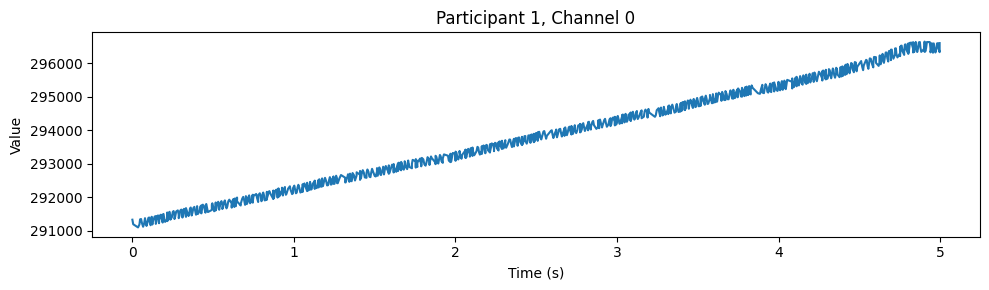

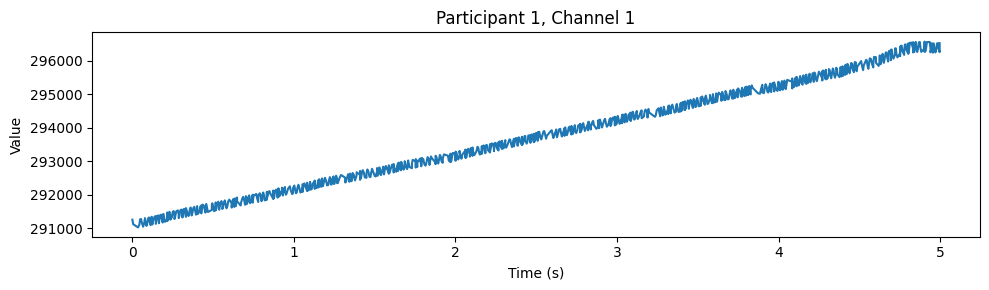

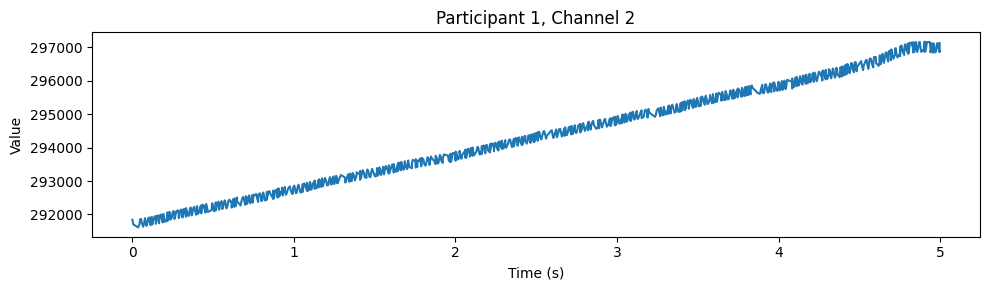

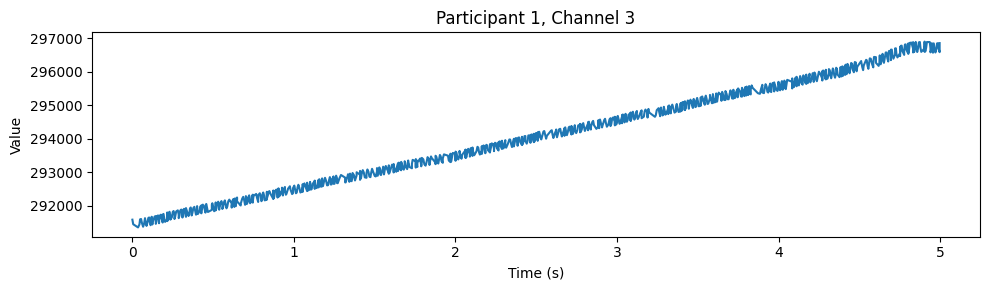

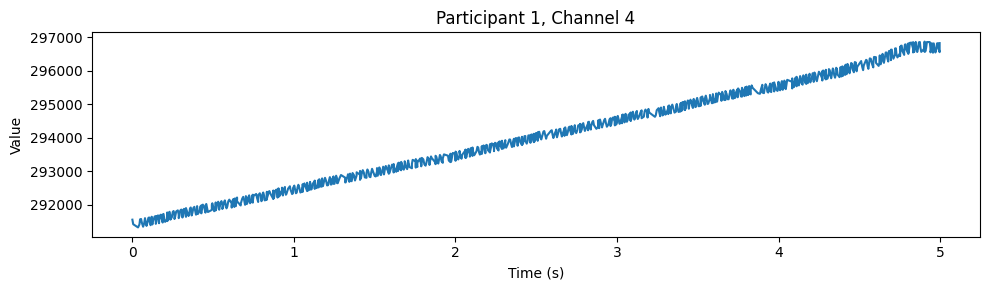

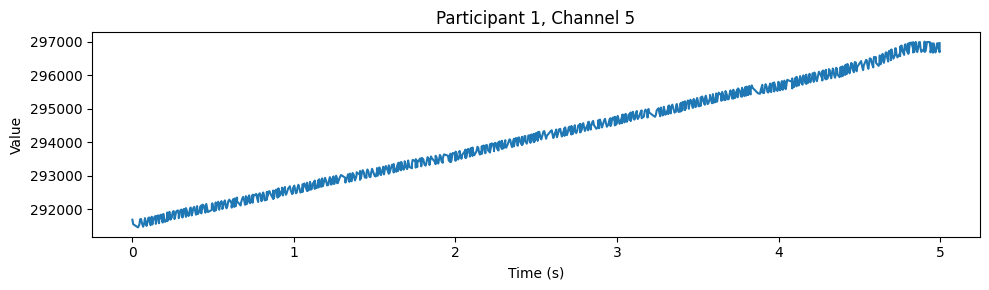

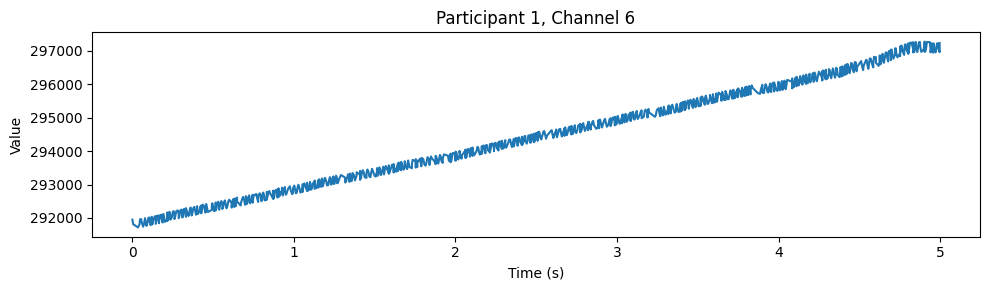

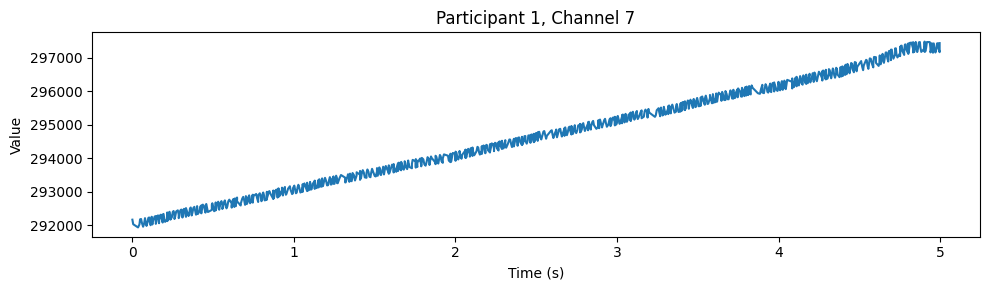

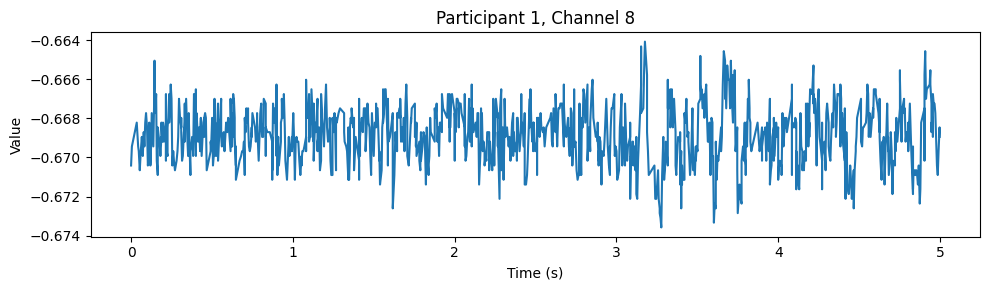

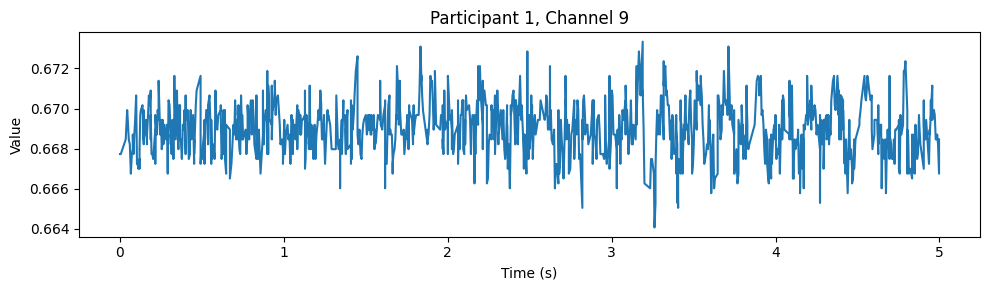

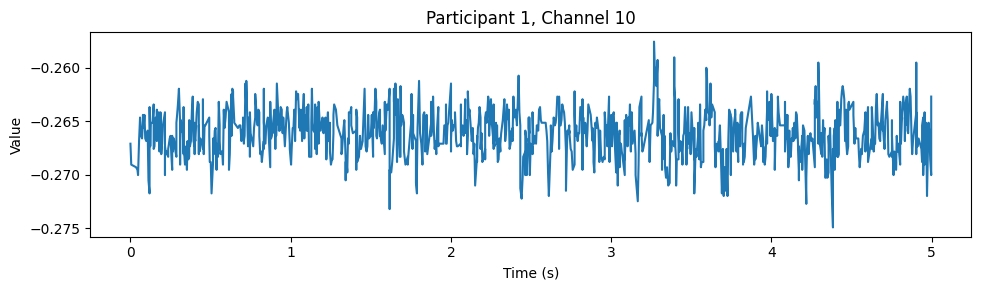

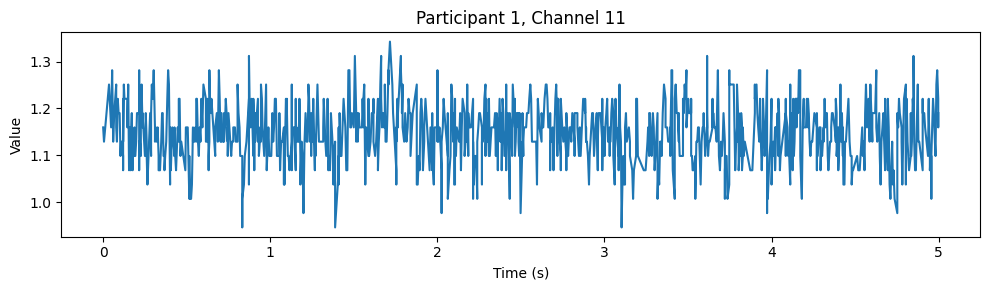

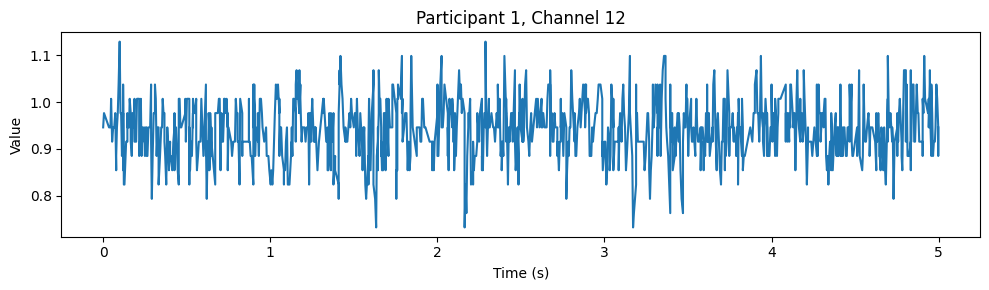

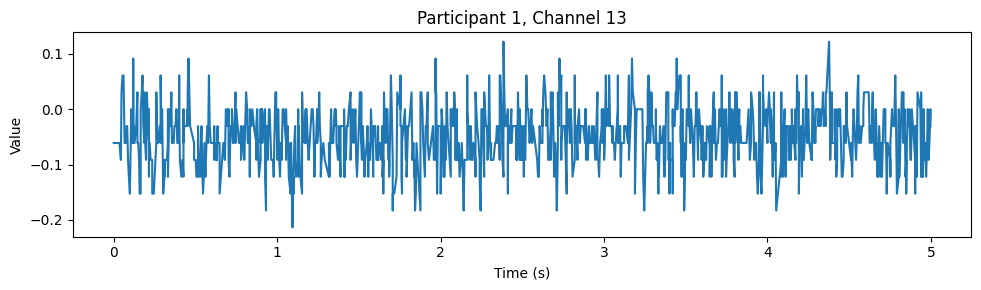

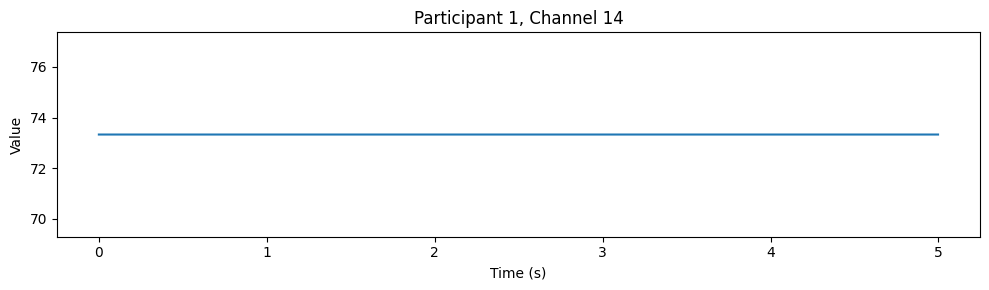

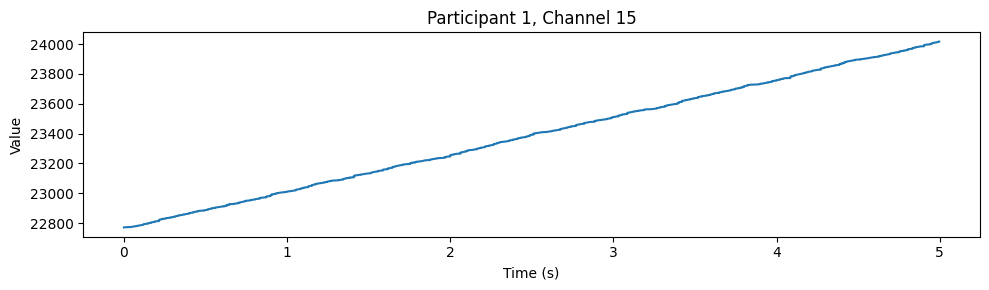

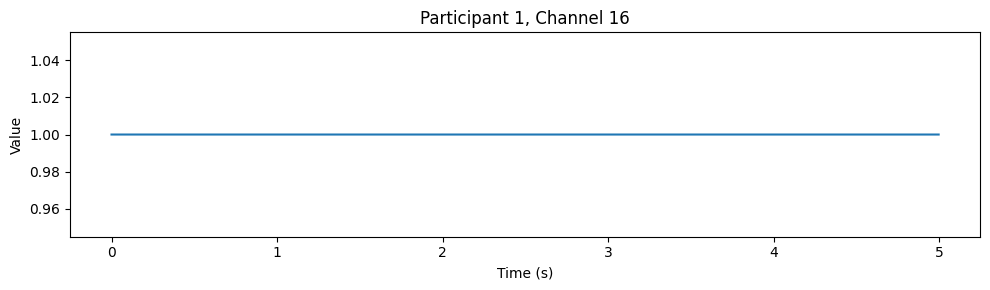

In [3]:
import matplotlib.pyplot as plt

X1 = data["eeg_samples_p1"]
t1 = data["eeg_timestamps_p1"]

# first 5 seconds
t0 = t1[0]
mask = (t1 >= t0) & (t1 <= t0 + 5)

Xseg = X1[mask]
tseg = t1[mask] - t0

for ch in range(Xseg.shape[1]):
    plt.figure(figsize=(10, 3))
    plt.plot(tseg, Xseg[:, ch])
    plt.title(f"Participant 1, Channel {ch}")
    plt.xlabel("Time (s)")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

In [4]:
X1 = data["eeg_samples_p1"]

stds = X1.std(axis=0)
means = X1.mean(axis=0)

print("Channels sorted by std:")
for ch in np.argsort(stds):
    print(f"Ch {ch:02d} | std={stds[ch]:.3f} | mean={means[ch]:.3f}")

Channels sorted by std:
Ch 08 | std=0.002 | mean=-0.668
Ch 09 | std=0.002 | mean=0.670
Ch 10 | std=0.002 | mean=-0.266
Ch 16 | std=0.059 | mean=0.997
Ch 11 | std=0.087 | mean=1.150
Ch 12 | std=0.095 | mean=0.953
Ch 13 | std=0.119 | mean=-0.058
Ch 14 | std=2.941 | mean=68.452
Ch 15 | std=15038.791 | mean=48817.918
Ch 00 | std=47111.578 | mean=376416.500
Ch 04 | std=47112.598 | mean=376634.719
Ch 01 | std=47122.984 | mean=376354.438
Ch 05 | std=47130.141 | mean=376806.062
Ch 06 | std=47131.805 | mean=377071.406
Ch 03 | std=47131.895 | mean=376704.969
Ch 02 | std=47142.746 | mean=376986.875
Ch 07 | std=47145.230 | mean=377306.938


## Test

In [2]:
import numpy as np

path = "data_test/testing_play_group_svm_decisions.npz"   # change if needed
data = np.load(path, allow_pickle=True)

print("Keys:")
print(data.files)

print("\nShapes:")
for k in data.files:
    arr = data[k]
    print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

print("\nPer-selection preview:")
for i in range(len(data["selection"])):
    print(
        f"selection={data['selection'][i]}, "
        f"best_row={data['best_row'][i]}, "
        f"best_col={data['best_col'][i]}, "
        f"symbol={data['symbol'][i]}, "
        f"time={data['decision_time'][i]}"
    )

print("\nPer-flash preview:")
for i in range(min(10, len(data["flash_selection"]))):
    print(
        f"sel={data['flash_selection'][i]}, "
        f"seq={data['flash_seq'][i]}, "
        f"flash={data['flash_number'][i]}, "
        f"kind={data['flash_kind'][i]}, "
        f"idx={data['flash_idx'][i]}, "
        f"target_prob={data['flash_target_prob'][i]:.4f}"
    )



Keys:
['selection', 'best_row', 'best_col', 'symbol', 'row_scores', 'col_scores', 'decision_time', 'flash_selection', 'flash_seq', 'flash_number', 'flash_kind', 'flash_idx', 'flash_target_prob', 'flash_time', 'flash_row_scores_after', 'flash_col_scores_after']

Shapes:
selection: shape=(4,), dtype=int32
best_row: shape=(4,), dtype=int32
best_col: shape=(4,), dtype=int32
symbol: shape=(4,), dtype=object
row_scores: shape=(4, 6), dtype=float32
col_scores: shape=(4, 6), dtype=float32
decision_time: shape=(4,), dtype=float64
flash_selection: shape=(477,), dtype=int32
flash_seq: shape=(477,), dtype=int32
flash_number: shape=(477,), dtype=int32
flash_kind: shape=(477,), dtype=object
flash_idx: shape=(477,), dtype=int32
flash_target_prob: shape=(477,), dtype=float32
flash_time: shape=(477,), dtype=float64
flash_row_scores_after: shape=(477, 6), dtype=float32
flash_col_scores_after: shape=(477, 6), dtype=float32

Per-selection preview:
selection=0, best_row=3, best_col=2, symbol=U, time=10372.

In [3]:
import numpy as np
import pandas as pd

path = "data_test/testing_play_group_svm_decisions.npz"
data = np.load(path, allow_pickle=True)

df_sel = pd.DataFrame({
    "selection": data["selection"],
    "best_row": data["best_row"],
    "best_col": data["best_col"],
    "symbol": data["symbol"],
    "decision_time": data["decision_time"],
})

df_flash = pd.DataFrame({
    "selection": data["flash_selection"],
    "seq": data["flash_seq"],
    "flash_number": data["flash_number"],
    "kind": data["flash_kind"],
    "idx": data["flash_idx"],
    "target_prob": data["flash_target_prob"],
    "flash_time": data["flash_time"],
})

print("\nSelection table:")
print(df_sel.head())

print("\nFlash table:")
print(df_flash.head(20))


Selection table:
   selection  best_row  best_col symbol  decision_time
0          0         3         2      U   10372.734112
1          1         1         4      K   10409.713538
2          2         5         3      8   10446.376395
3          3         1         5      L   10482.909767

Flash table:
    selection  seq  flash_number kind  idx  target_prob    flash_time
0           0    0             0  col    0     0.809118  10337.582041
1           0    0             1  col    2     0.847291  10337.883484
2           0    0             2  row    5     0.806037  10338.191693
3           0    0             4  row    3     0.484079  10338.835666
4           0    0             5  col    1     0.488906  10339.147926
5           0    0             6  row    2     0.311408  10339.433867
6           0    0             7  col    5     0.174338  10339.711919
7           0    0             8  row    1     0.225251  10340.022809
8           0    0             9  row    0     0.189507  10340.